# BTSP on a linear track (2-compartment neurons)

**Objective:** Compare hyperparameters and evaluate spatial features pyramidal neurons learn to encode.

* Linear track (periodic)
* Agent navigates in a specific direction (and eventually back and forth)
* Target object located partway along the track.
* Two-compartment pyramidal neuron layer:
  * Somatic input: uniformly distributed Gaussian place cells (plastic)
  * Dendritic input: Target object-encoding cell (fixed)
  * Filtered dendritic self-inhibition
  * 1 pyramidal neuron only
* Learning:
  * BTSP learning: strong learning with a broad kernel, occurring when a neuron's activation passes a predetermined threshold.

In [1]:
import copy
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from ratinabox import utils as rutils
from tqdm import tqdm

from predhpc import agent, env, plot_fcts, run_manager
from predhpc.neurons import riab_neurons, learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import plot_util, params_util, animate_util, gen_util

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="solid 1D boundary", category=UserWarning
)
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
import importlib
importlib.reload(agent)
importlib.reload(env)
importlib.reload(plot_fcts)
importlib.reload(run_manager)
importlib.reload(riab_neurons)
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(plot_util)
importlib.reload(params_util)
importlib.reload(animate_util)
importlib.reload(gen_util);

## Hyperparameters and functions

In [5]:
START_BTSP = 0
NUM_STEPS = 5000

BTSP_LR_FACT = 150

env_params = params_util.get_env_params(
    environment="linear",
)

target_position = np.asarray([env_params["scale"] / 2])
agent_params = params_util.get_agent_params(
    environment="linear",
    target_position=target_position,
    speed_mean=0.08,
    speed_std=0.01,
)

moved_target_position = np.asarray([env_params["scale"] / 3 * 2])

Obj_params = params_util.get_Obj_params(environment="linear")

PC_params = params_util.get_PC_params(
    environment="linear", 
    n=40
)

In [6]:
Hebbian_learn = False
record_weights_freq = 100

Pyr_params = params_util.get_Pyr_params(
    environment="linear", 
    n=1, 
    two_compartment=True, 
    BTSP=True, 

    single_BTSP=False,
    BTSP_distance_prop=None,

    dend_w_init_loc=0.4,
    soma_BTSP_lr_fact=BTSP_LR_FACT,  # BTSP clamp
)

## 1. Single direction

100%|██████████████████████████████████████| 5000/5000 [00:05<00:00, 919.32it/s]


Trajectory lengths (3) to date: 50.00 +/- 1.24 sec each
Trajectory lengths (3) to date: 1666.67 +/- 41.25 steps each
1 BTSP event(s).


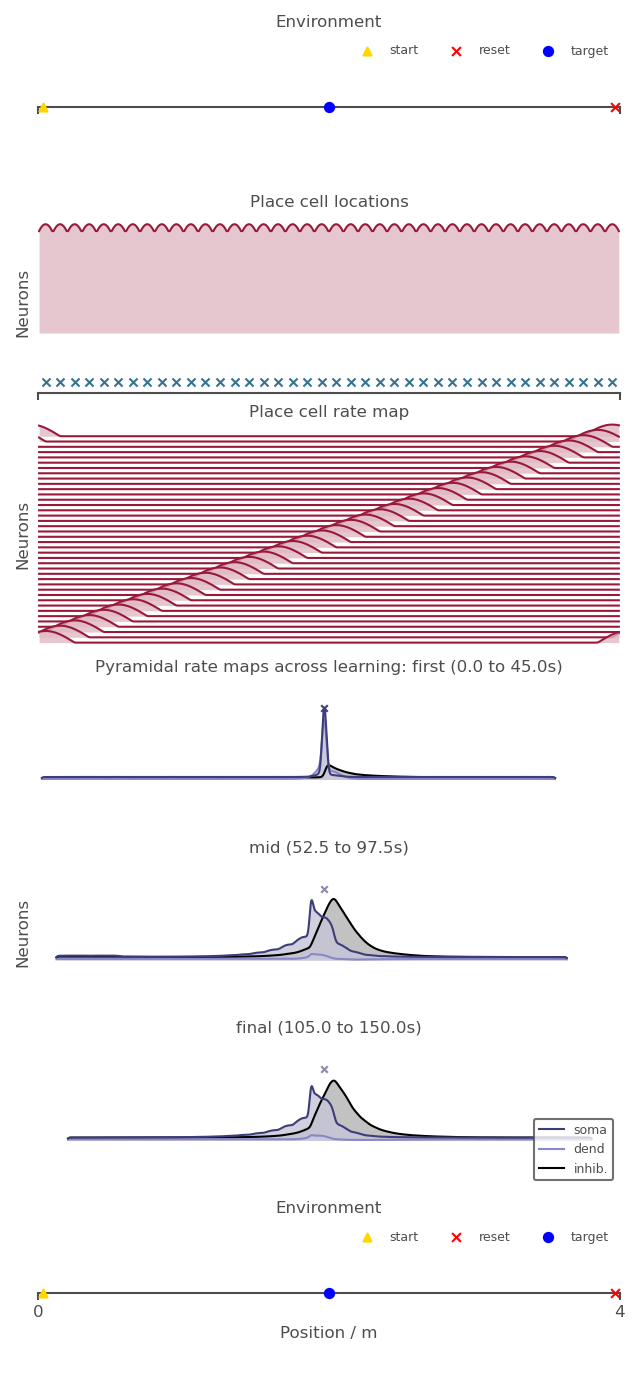

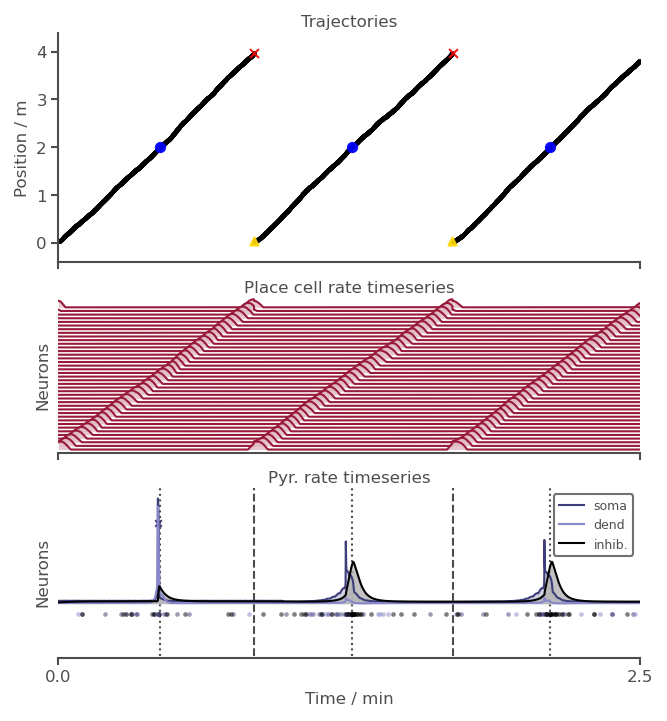

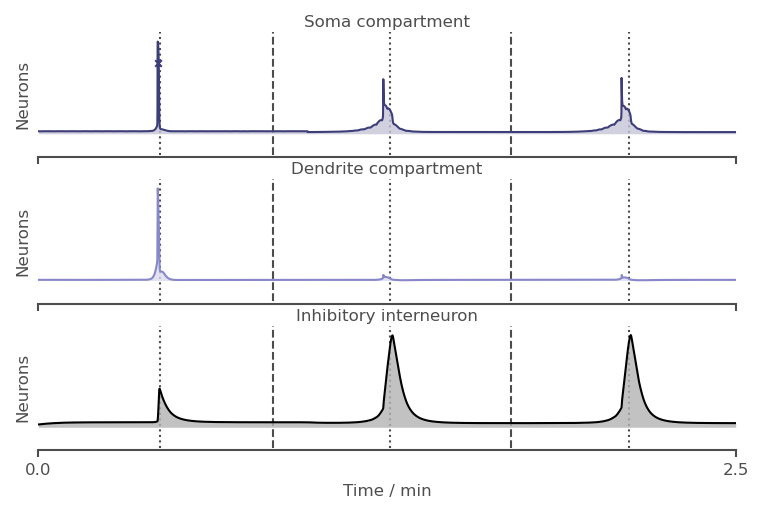

In [7]:
Env = env.Environment(params=env_params)

Ag = agent.ResetableAgent(Env, params=agent_params)

Objs = object_neurons.ObjectCells(Ag, params=Obj_params)
PCs = riab_neurons.PlaceCells(Ag, params=PC_params)

Pyr_params["dend_input_layers"] = [Objs]
Pyr_params["soma_input_layers"] = [PCs]
Pyrs = two_comp_neurons.TwoCompLayer(Ag, params=Pyr_params)
Pyrs.set_learn(soma=Hebbian_learn, dend=False, inhibit=False)
Pyrs.set_BTSP_learn(soma=False, dend=False)

BTSP_started = False
num_BTSP_to_date = len(Pyrs.SomaCompartment.history["BTSP_events"])
Pyrs_weights, Pyrs_weights_t = list(), list()
for i in tqdm(range(NUM_STEPS)):
    Ag.update()
    Objs.update()
    PCs.update()
    Pyrs.update()

    if not BTSP_started and len(Ag.trajectory_df) >= START_BTSP:
        Pyrs.set_BTSP_learn(soma=True, dend=False)
        BTSP_started = True

    if not i % record_weights_freq:
        Pyrs_weights.append(copy.deepcopy(Pyrs.SomaCompartment.inputs["PCs"]["w"]))
        Pyrs_weights_t.append(Ag.t)

Pyrs_weights.append(copy.deepcopy(Pyrs.SomaCompartment.inputs["PCs"]["w"]))
Pyrs_weights_t.append(Ag.t)
num_BTSP_events = len(Pyrs.SomaCompartment.history["BTSP_events"]) - num_BTSP_to_date

Ag.log_trajectory_stats_to_date(True)
Ag.log_trajectory_stats_to_date(False)
print(f"{num_BTSP_events} BTSP event(s).")

env_axes = run_manager.plot_1D_spatial_info(Ag, PCs, Pyrs);
time_axes = run_manager.plot_1D_time_info(Ag, PCs, Pyrs)
Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max");

### Single direction track groundtruth rate maps

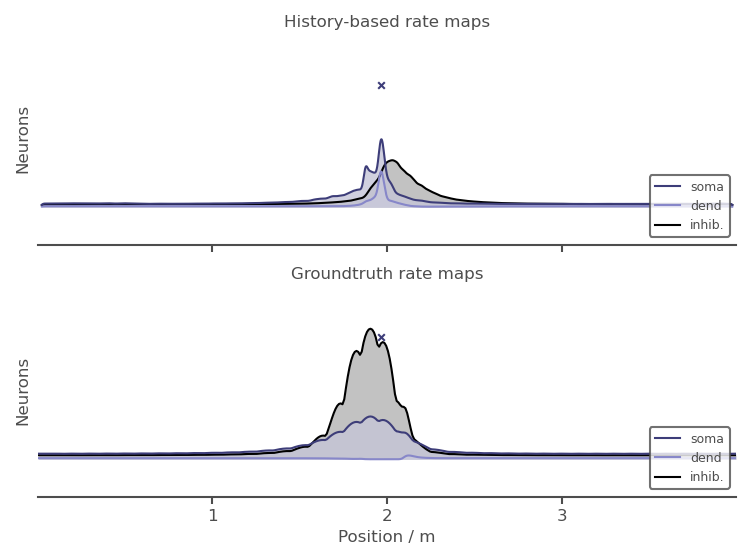

In [8]:
fig, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True)
Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Groundtruth rate maps");

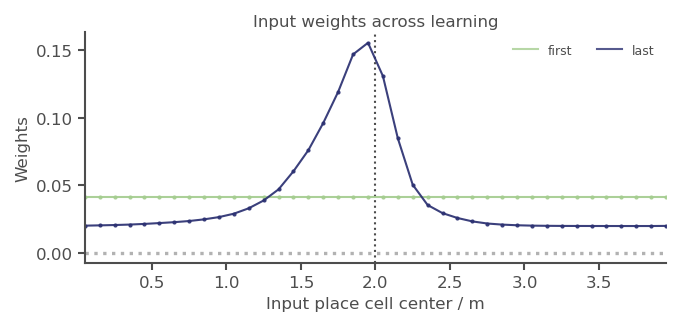

In [9]:
ws = [Pyrs.SomaCompartment.inputs["PCs"][key] for key in ["w_init", "w"]]
plot_fcts.plot_1D_input_place_cell_weights(ws, Pyrs.SomaCompartment.inputs["PCs"]["layer"]);

### Single direction inputs and activations

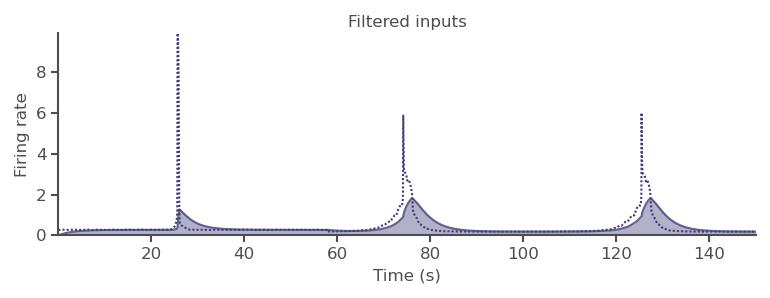

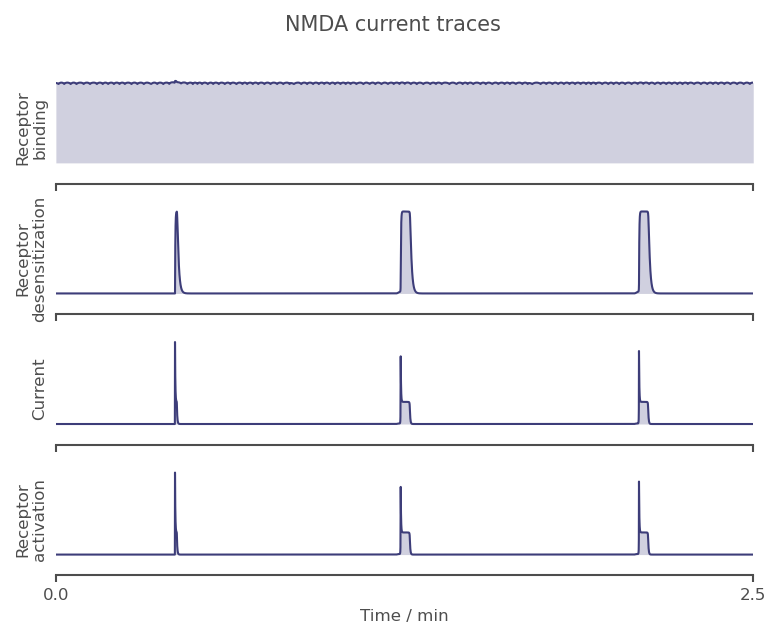

In [10]:
Pyrs.DendriteInhibition.plot_filtered("Pyr_TwoComp_soma")
Pyrs.SomaCompartment.NMDACurrent.plot_timeseries(datatypes="all");

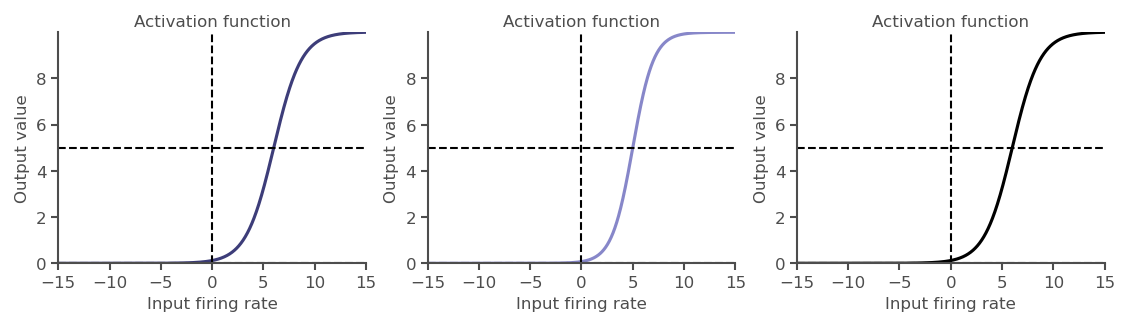

In [11]:
fig, ax1D = plt.subplots(1, 3, figsize=[9, 2])
Pyrs.SomaCompartment.plot_activation_function(sub_ax=ax1D[0])
Pyrs.DendriteCompartment.plot_activation_function(sub_ax=ax1D[1])
Pyrs.DendriteInhibition.plot_activation_function(sub_ax=ax1D[2]);

### Single direction BTSP stats

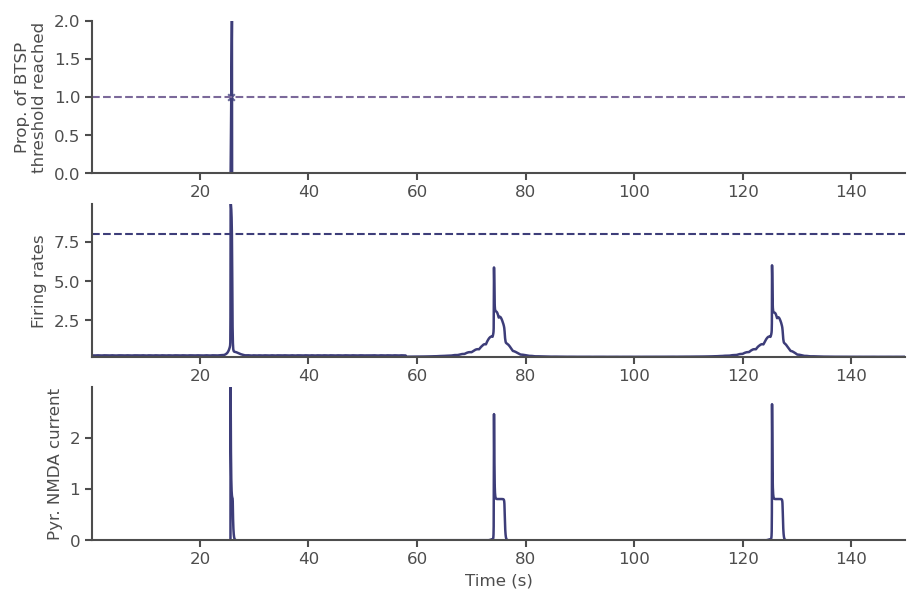

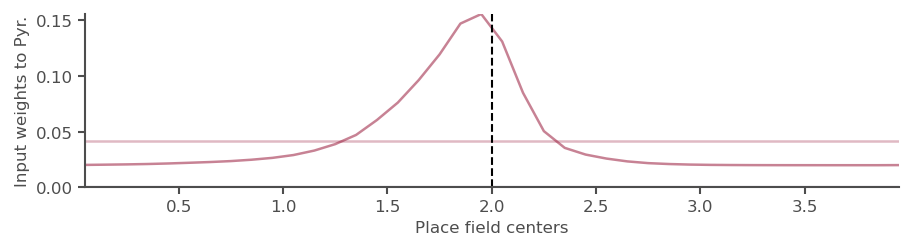

In [12]:
height, width = 1.5, 7
fig, ax1D = plt.subplots(3, 1, figsize=(width, height * 3))
Pyrs.SomaCompartment.plot_BTSP_ramp(axes=ax1D)

fig, sub_ax = plt.subplots(figsize=(width, height))
alphas = np.linspace(0.3, 0.9, len(Pyrs_weights))
prev_weights = None
for a, alpha in enumerate(alphas):
    weights = Pyrs_weights[a][0]
    if prev_weights is not None and (prev_weights == weights).all():
        continue
    sub_ax.plot(
        PCs.place_cell_centres[:, 0], weights, lw=1.2, 
        color=PCs.color, alpha=alpha
    )
    prev_weights = weights
    
sub_ax.axvline(Pyrs.Agent.target_position[0], ls="dashed", color="k")
sub_ax.set_xlabel("Place field centers")
sub_ax.set_ylabel("Input weights to Pyr.")
sub_ax.axhline(0, zorder=-12)
sub_ax.spines[["top", "right"]].set_visible(False);

### Pre BTSP kernel

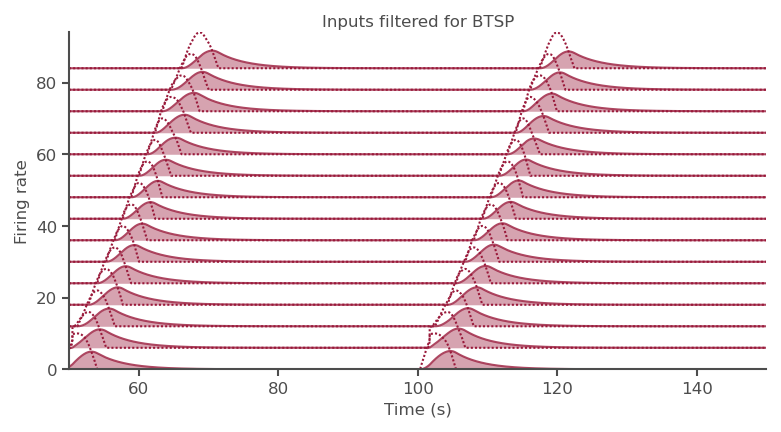

In [13]:
Pyrs.SomaCompartment.plot_filtered_for_BTSP("PCs", t_start=-100, chosen_neurons=np.arange(15));

### Post BTSP kernel

BTSP events applied after 1073.00 steps (32.19 sec.) (num steps: 1073).


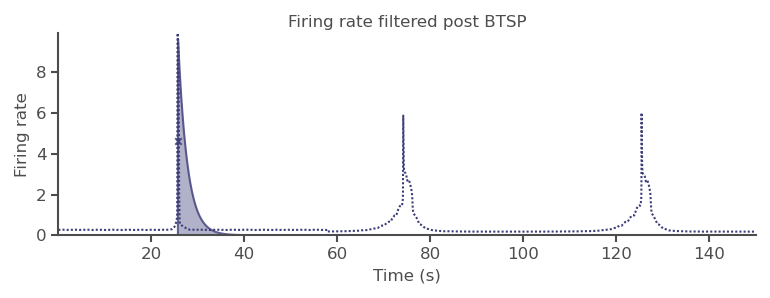

In [14]:
Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
Pyrs.SomaCompartment.plot_filtered_for_BTSP();

## 2. Move target
Target moved to a new location after initial BTSP learning.

100%|██████████████████████████████████████| 5000/5000 [00:05<00:00, 958.37it/s]


Trajectory lengths (6) to date: 50.00 +/- 1.55 sec each
Trajectory lengths (6) to date: 1666.67 +/- 51.53 steps each
1 additional BTSP event(s).


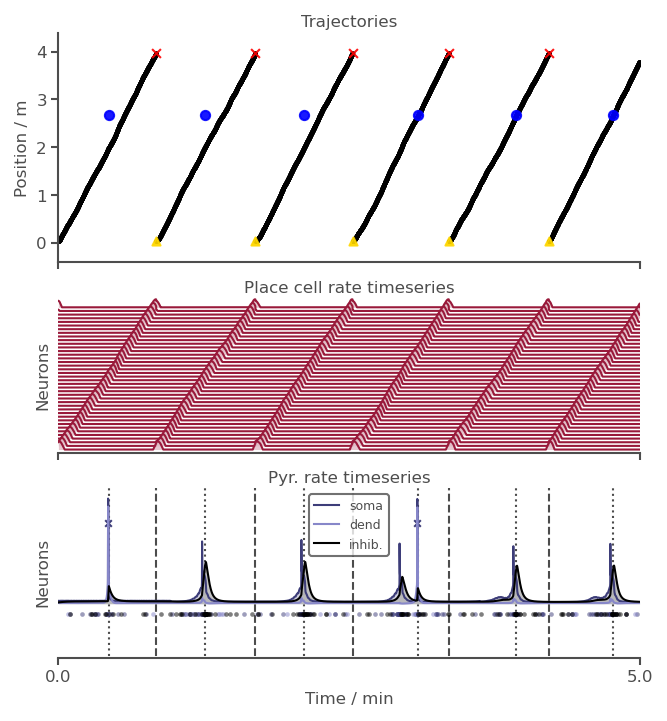

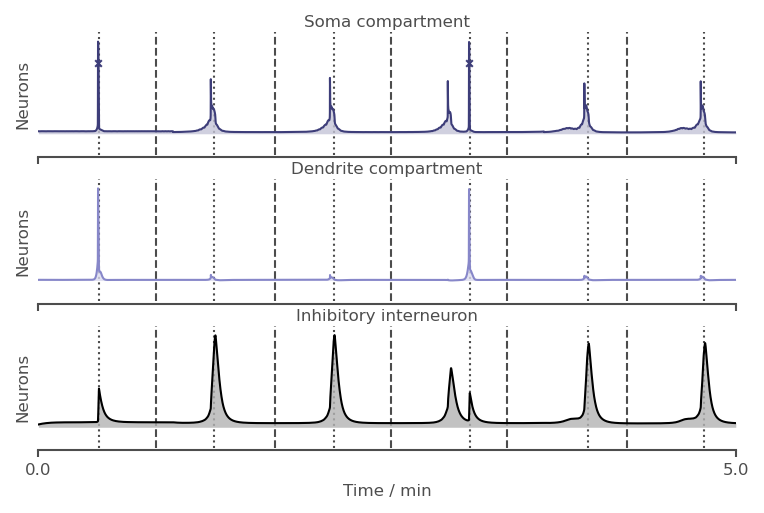

In [15]:
move_time = Ag.t

Ag.set_target_position(moved_target_position)

Pyrs.set_learn(soma=Hebbian_learn, dend=False, inhibit=False)
Pyrs.set_BTSP_learn(soma=False, dend=False)
num_BTSP_to_date = len(Pyrs.SomaCompartment.history["BTSP_events"])

BTSP_started = False
leng_traj_df = len(Ag.trajectory_df)
num_BTSP_to_date = len(Pyrs.SomaCompartment.history["BTSP_events"])
start_weights = len(Pyrs_weights)
for i in tqdm(range(NUM_STEPS)):
    Ag.update()
    Objs.update()
    PCs.update()
    Pyrs.update()

    if not BTSP_started and len(Ag.trajectory_df) >= START_BTSP + leng_traj_df - 1:
        Pyrs.set_BTSP_learn(soma=True, dend=False)
        BTSP_started = True

    if not i % record_weights_freq:
        Pyrs_weights.append(copy.deepcopy(Pyrs.SomaCompartment.inputs["PCs"]["w"]))
        Pyrs_weights_t.append(Ag.t)

Pyrs_weights.append(copy.deepcopy(Pyrs.SomaCompartment.inputs["PCs"]["w"]))
Pyrs_weights_t.append(Ag.t)
num_BTSP_events = len(Pyrs.SomaCompartment.history["BTSP_events"]) - num_BTSP_to_date

Ag.log_trajectory_stats_to_date(True)
Ag.log_trajectory_stats_to_date(False)
print(f"{num_BTSP_events} additional BTSP event(s).")

time_axes = run_manager.plot_1D_time_info(Ag, PCs, Pyrs)
Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max");

### Moved target groundtruth rate maps

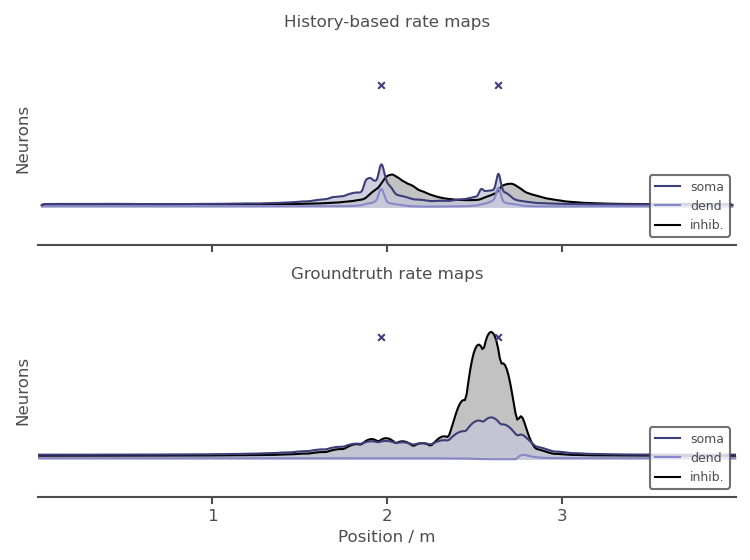

In [16]:
fig, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True)
Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Groundtruth rate maps");

### Moved target BTSP stats

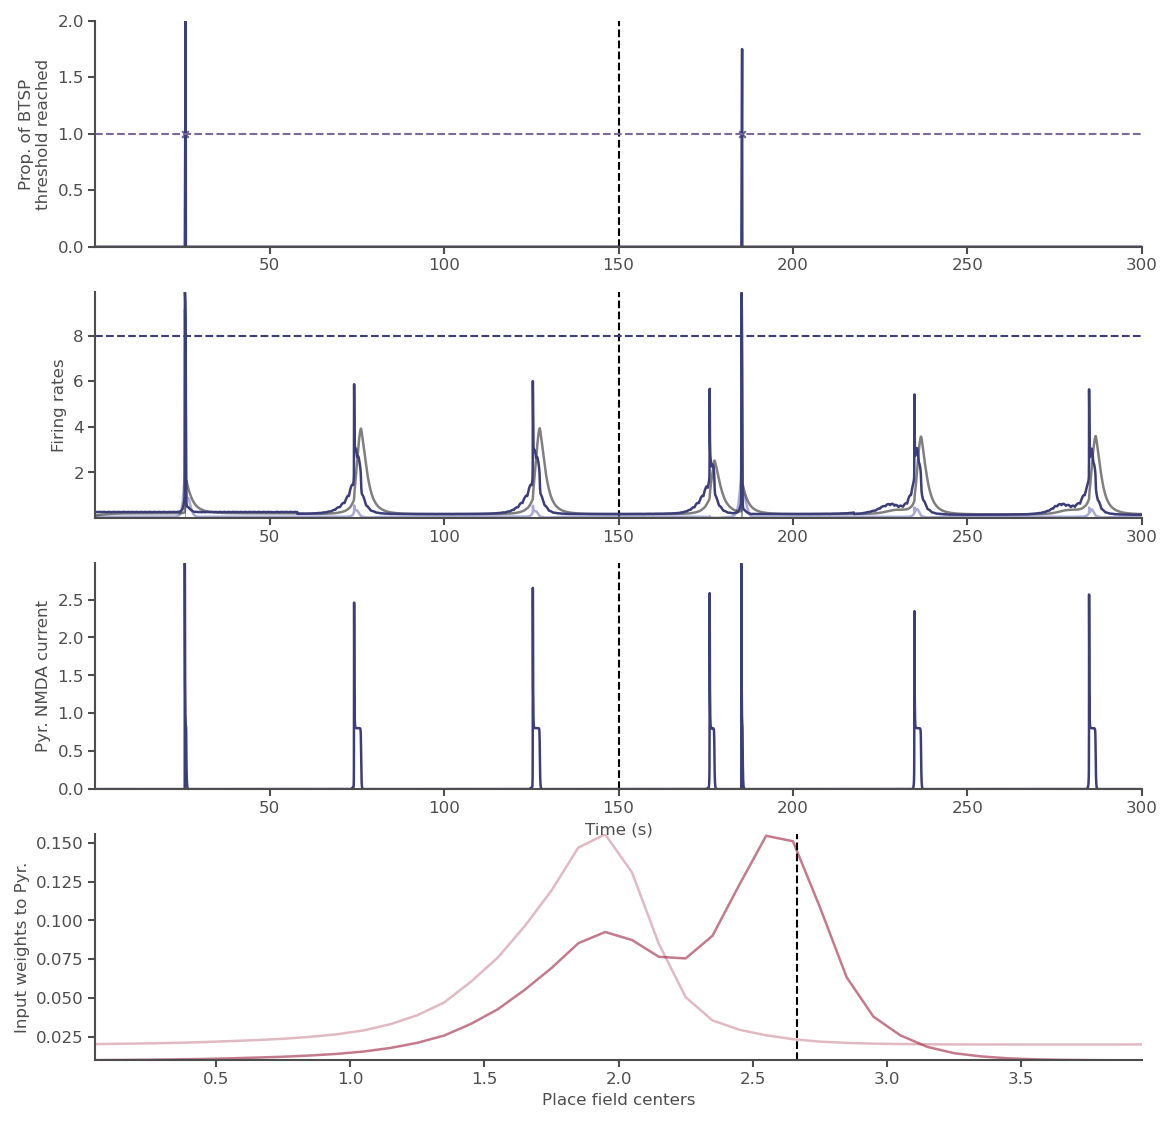

In [17]:
fig, ax1D = plt.subplots(4, 1, figsize=(9, 9))
Pyrs.SomaCompartment.plot_BTSP_ramp(axes=ax1D[:3])
ax1D[1].plot(
    Pyrs.DendriteCompartment.history["t"], Pyrs.DendriteCompartment.history["firingrate"], 
    lw=1.2, alpha=0.7, zorder=-10, label="dend", color=Pyrs.DendriteCompartment.color
)
ax1D[1].plot(
    Pyrs.DendriteInhibition.history["t"], Pyrs.DendriteInhibition.history["firingrate"], 
    lw=1.2, alpha=0.5, zorder=-10, label="inhib.", color=Pyrs.DendriteInhibition.color
)

for sub_ax in ax1D[:3]:
    sub_ax.axvline(move_time, ls="dashed", color="k", zorder=-12)

alphas = np.linspace(0.3, 0.9, len(Pyrs_weights[start_weights:]))
prev_weights = None
for a, alpha in enumerate(alphas):
    weights = Pyrs_weights[a + start_weights][0]
    if prev_weights is not None and (prev_weights == weights).all():
        continue
    ax1D[3].plot(
        PCs.place_cell_centres[:, 0], weights, lw=1.2, 
        color=PCs.color, alpha=alpha
    )
    prev_weights = weights

ax1D[3].axvline(Pyrs.Agent.target_position[0], ls="dashed", color="k")
ax1D[3].set_xlabel("Place field centers")
ax1D[3].set_ylabel("Input weights to Pyr.")
ax1D[3].spines[["top", "right"]].set_visible(False);

BTSP events applied after 1072.50 steps (32.17 sec.) (num steps: 1073, 1072).


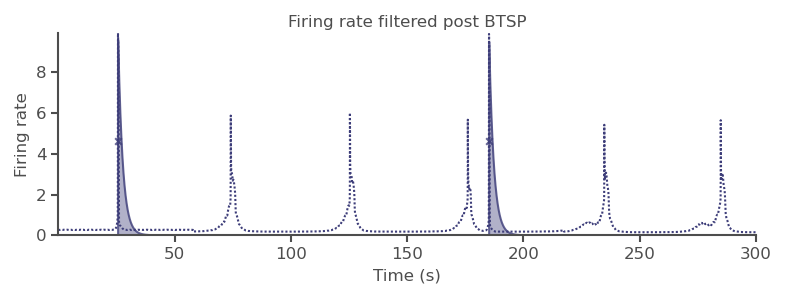

In [18]:
Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
Pyrs.SomaCompartment.plot_filtered_for_BTSP();

## 3. Switch to back and forth navigation
Agent set to travel back and forth along the track.

100%|██████████████████████████████████████| 5000/5000 [00:05<00:00, 926.79it/s]


Trajectory lengths (9) to date: 50.00 +/- 1.49 sec each
Trajectory lengths (9) to date: 1666.67 +/- 49.61 steps each
1 additional BTSP events.


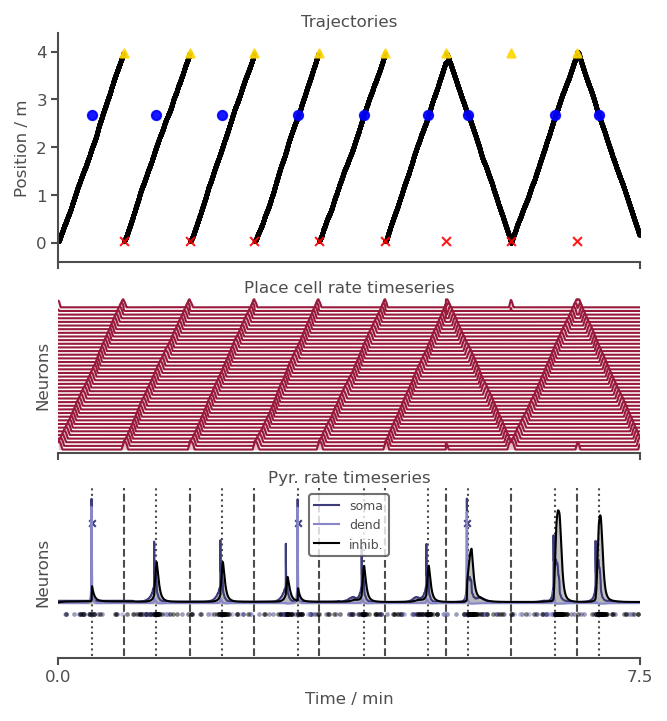

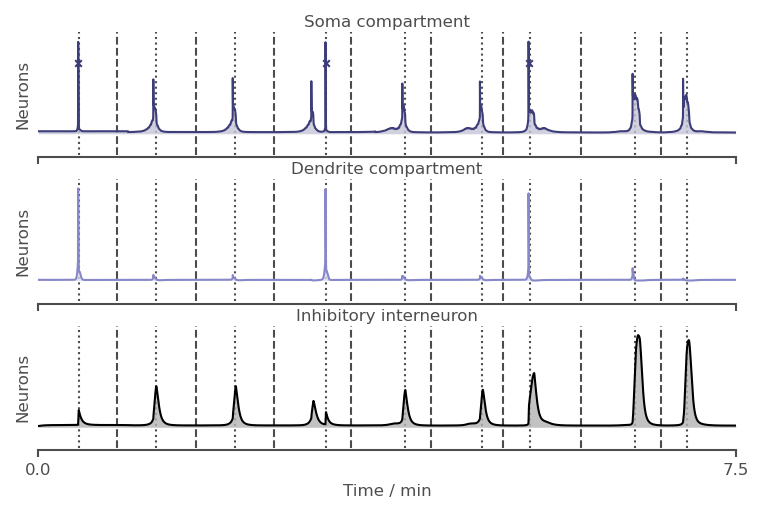

In [19]:
bf_start_time = Ag.t

Ag.reverse(reset=True)
reverse_points = [Ag.reset_position, Ag.start_position]
Ag.reset_position, Ag.start_position = [np.around(point) for point in reverse_points]
check_pt = 0

Pyrs.set_learn(soma=Hebbian_learn, dend=False, inhibit=False)
Pyrs.set_BTSP_learn(soma=False, dend=False)

BTSP_started = False
leng_traj_df = len(Ag.trajectory_df)
num_BTSP_to_date = len(Pyrs.SomaCompartment.history["BTSP_events"])
start_weights = len(Pyrs_weights)
for i in tqdm(range(NUM_STEPS)):
    Ag.update()
    Objs.update()
    PCs.update()
    Pyrs.update()

    if not BTSP_started and len(Ag.trajectory_df) >= START_BTSP + leng_traj_df - 1:
        Pyrs.set_BTSP_learn(soma=True, dend=False)
        BTSP_started = True
        
    if Ag.check_if_position_reached(reverse_points[check_pt]):
        Ag.reverse(reset=True)
        check_pt = 1 - check_pt

    if not i % record_weights_freq:
        Pyrs_weights.append(copy.deepcopy(Pyrs.SomaCompartment.inputs["PCs"]["w"]))
        Pyrs_weights_t.append(Ag.t)

Ag.reset_position, Ag.start_position = reverse_points[check_pt], reverse_points[1 - check_pt]

Pyrs_weights.append(copy.deepcopy(Pyrs.SomaCompartment.inputs["PCs"]["w"]))
Pyrs_weights_t.append(Ag.t)

num_BTSP_events = len(Pyrs.SomaCompartment.history["BTSP_events"]) - num_BTSP_to_date

Ag.log_trajectory_stats_to_date(True)
Ag.log_trajectory_stats_to_date(False)
print(f"{num_BTSP_events} additional BTSP events.")

time_axes = run_manager.plot_1D_time_info(Ag, PCs, Pyrs)
Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max");

### Back and forth track groundtruth rate maps

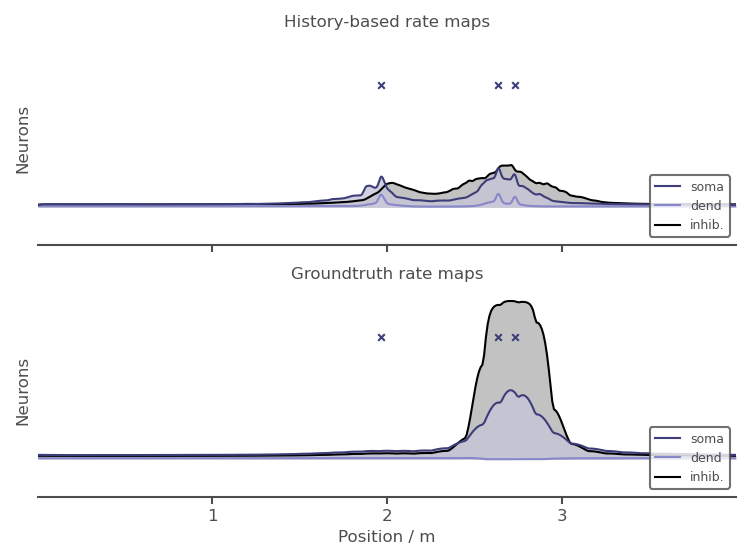

In [20]:
fig, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True)
Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Groundtruth rate maps");

### Back and forth track BTSP stats

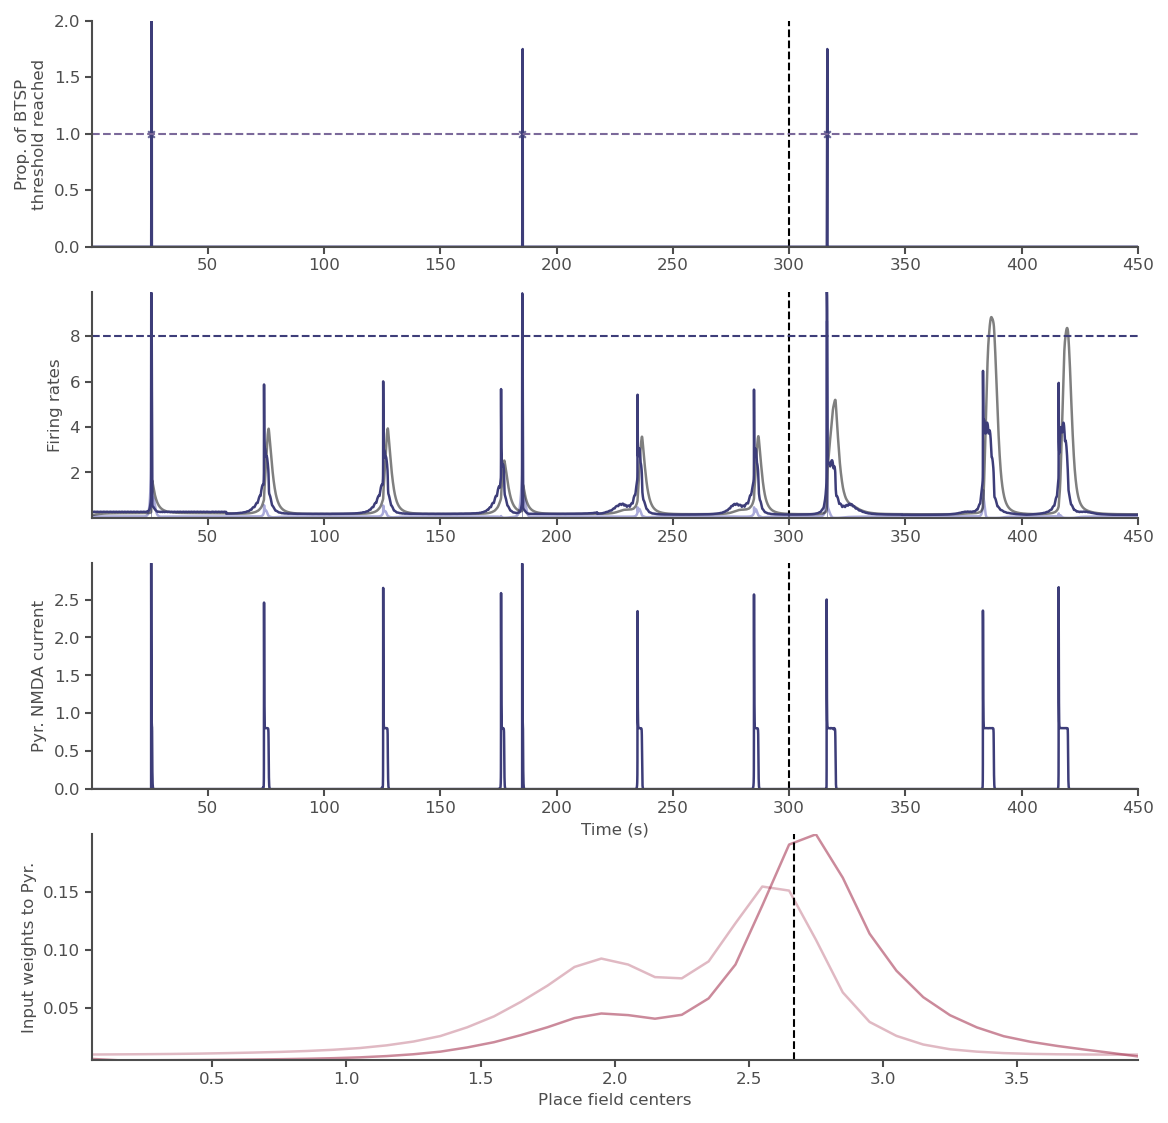

In [21]:
fig, ax1D = plt.subplots(4, 1, figsize=(9, 9))
Pyrs.SomaCompartment.plot_BTSP_ramp(axes=ax1D[:3])
ax1D[1].plot(
    Pyrs.DendriteCompartment.history["t"], Pyrs.DendriteCompartment.history["firingrate"], 
    lw=1.2, alpha=0.7, zorder=-10, label="dend", color=Pyrs.DendriteCompartment.color
)
ax1D[1].plot(
    Pyrs.DendriteInhibition.history["t"], Pyrs.DendriteInhibition.history["firingrate"], 
    lw=1.2, alpha=0.5, zorder=-10, label="inhib.", color=Pyrs.DendriteInhibition.color
)

for sub_ax in ax1D[:3]:
    sub_ax.axvline(bf_start_time, ls="dashed", color="k", zorder=-12)

alphas = np.linspace(0.3, 0.9, len(Pyrs_weights[start_weights:]))
prev_weights = None
for a, alpha in enumerate(alphas):
    weights = Pyrs_weights[a + start_weights][0]
    if prev_weights is not None and (prev_weights == weights).all():
        continue
    ax1D[3].plot(
        PCs.place_cell_centres[:, 0], weights, lw=1.2, 
        color=PCs.color, alpha=alpha
    )
    prev_weights = weights

ax1D[3].axvline(Pyrs.Agent.target_position[0], ls="dashed", color="k")
ax1D[3].set_xlabel("Place field centers")
ax1D[3].set_ylabel("Input weights to Pyr.")
ax1D[3].spines[["top", "right"]].set_visible(False);

BTSP events applied after 1072.67 steps (32.18 sec.) (num steps: 1073, 1072, 1073).


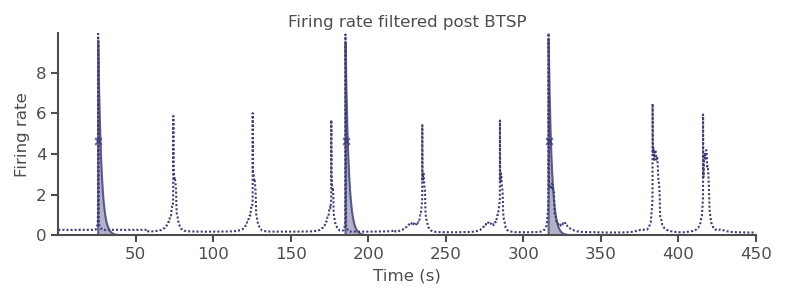

In [22]:
Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
Pyrs.SomaCompartment.plot_filtered_for_BTSP();

### Animate results

In [23]:
ANIMATE = False

In [24]:
if ANIMATE and (Ag.start_position > Ag.reset_position).all():
    Ag.reverse()

In [25]:
if ANIMATE:
    traj_kwargs = {
        "previous_target_positions": [target_position],
        "target_move_times": [move_time],
        "addendum": "single direction",
    }
    
    anim = animate_util.animate(
        Ag, 
        Pyrs, 
        Pyrs_weights,
        Pyrs_weights_t,
        t_start=0, 
        t_end=move_time, 
        fps=5, 
        speed_up=6, 
        savename="linear_track_timeseries_initial",
        embed_limit=40.0,
        autosave=True,
        traj_kwargs=traj_kwargs,
        )
    anim

In [26]:
if ANIMATE:
    traj_kwargs = {
        "previous_target_positions": [target_position],
        "target_move_times": [move_time],
        "addendum": "target moved",
    }
    
    anim = animate_util.animate(
        Ag, 
        Pyrs, 
        Pyrs_weights,
        Pyrs_weights_t,
        t_start=move_time, 
        t_end=bf_start_time, 
        fps=5, 
        speed_up=6, 
        savename="linear_track_timeseries_moved",
        embed_limit=40.0,
        autosave=True,
        traj_kwargs=traj_kwargs,
        )
    anim

In [27]:
if ANIMATE:
    traj_kwargs = {
        "previous_target_positions": [target_position],
        "target_move_times": [move_time],
        "addendum": "back and forth",
    }
    
    anim = animate_util.animate(
        Ag, 
        Pyrs, 
        Pyrs_weights,
        Pyrs_weights_t,
        t_start=bf_start_time, 
        t_end=None, 
        fps=5, 
        speed_up=6, 
        savename="linear_track_timeseries_bf",
        embed_limit=40.0,
        autosave=True,
        traj_kwargs=traj_kwargs,
        )
    anim

In [28]:
if ANIMATE:
    traj_kwargs = {
        "previous_target_positions": [target_position],
        "target_move_times": [move_time],
    }
    
    anim = animate_util.animate(
        Ag, 
        Pyrs, 
        Pyrs_weights,
        Pyrs_weights_t,
        t_start=0, 
        t_end=None, 
        fps=5, 
        speed_up=6, 
        savename="linear_track_timeseries_full",
        embed_limit=40.0,
        autosave=True,
        traj_kwargs=traj_kwargs,
        )
    anim

## 4. Remove object from track
Object removed from track.

100%|██████████████████████████████████████| 5000/5000 [00:05<00:00, 939.87it/s]


Trajectory lengths (13) to date: 46.15 +/- 13.23 sec each
Trajectory lengths (13) to date: 1538.46 +/- 440.93 steps each
0 additional BTSP events.


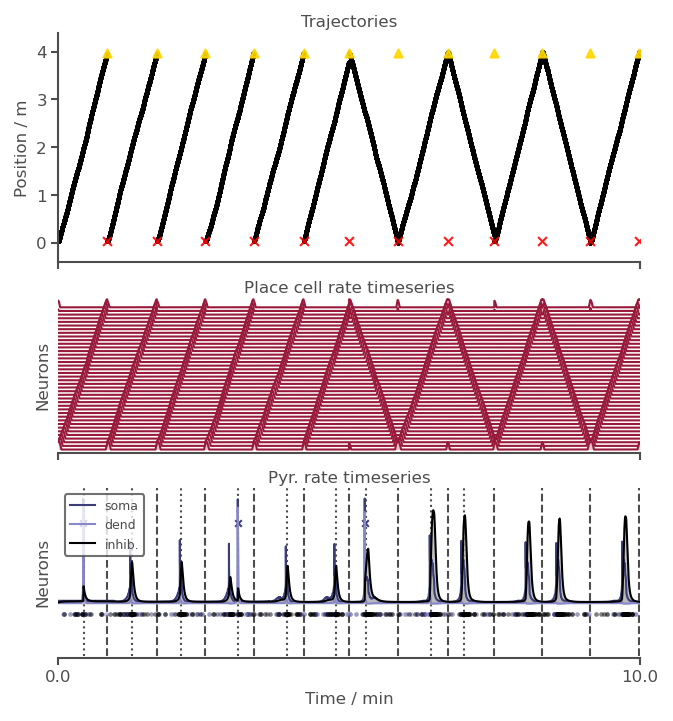

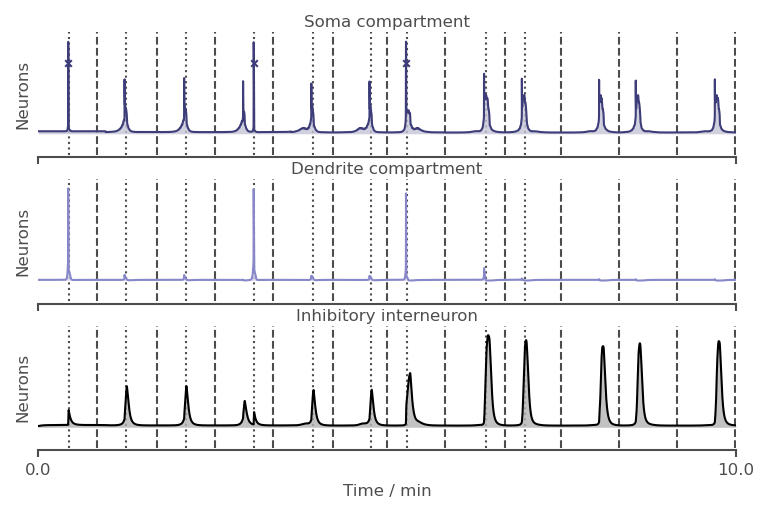

In [29]:
disap_start_time = Ag.t

Ag.set_target_position(None)
Objs.set_to_dummy()

Ag.reverse(reset=True)
reverse_points = [Ag.reset_position, Ag.start_position]
Ag.reset_position, Ag.start_position = [np.around(point) for point in reverse_points]
check_pt = 0

Pyrs.set_learn(soma=Hebbian_learn, dend=False, inhibit=False)
Pyrs.set_BTSP_learn(soma=False, dend=False)

BTSP_started = False
leng_traj_df = len(Ag.trajectory_df)
num_BTSP_to_date = len(Pyrs.SomaCompartment.history["BTSP_events"])
start_weights = len(Pyrs_weights)
for i in tqdm(range(NUM_STEPS)):
    Ag.update()
    Objs.update()
    PCs.update()
    Pyrs.update()

    if not BTSP_started and len(Ag.trajectory_df) >= START_BTSP + leng_traj_df - 1:
        Pyrs.set_BTSP_learn(soma=True, dend=False)
        BTSP_started = True
        
    if Ag.check_if_position_reached(reverse_points[check_pt]):
        Ag.reverse(reset=True)
        check_pt = 1 - check_pt

    if not i % record_weights_freq:
        Pyrs_weights.append(copy.deepcopy(Pyrs.SomaCompartment.inputs["PCs"]["w"]))
        Pyrs_weights_t.append(Ag.t)

Ag.reset_position, Ag.start_position = reverse_points[check_pt], reverse_points[1 - check_pt]

Pyrs_weights.append(copy.deepcopy(Pyrs.SomaCompartment.inputs["PCs"]["w"]))
Pyrs_weights_t.append(Ag.t)

num_BTSP_events = len(Pyrs.SomaCompartment.history["BTSP_events"]) - num_BTSP_to_date

Ag.log_trajectory_stats_to_date(True)
Ag.log_trajectory_stats_to_date(False)
print(f"{num_BTSP_events} additional BTSP events.")

time_axes = run_manager.plot_1D_time_info(Ag, PCs, Pyrs)
Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max");

### Before / After

In [30]:
def plot_before_vs_after(Pyrs, Objs, disap_start_time=0, pre=60, Pyrs_norm_by=None):

    fig, axes = plt.subplots(4, 2, sharex="col", sharey=True, figsize=(8, 4))

    pre_disap_time = disap_start_time - pre
    col_times = [(pre_disap_time, disap_start_time), (disap_start_time, None)]
    
    for c, (start, end) in enumerate(col_times):
        Objs.plot_rate_timeseries(t_start=start, t_end=end, sub_ax=axes[0, c])
        axes[0, c].set_xlabel("")
        axes[0, c].set_title("EC input")
        Pyrs.plot_rate_timeseries(separate_axes=True, t_start=start, t_end=end, ax=axes[1:, c], norm_by="shared_max")
        
        for sub_ax in axes[:, c][:-1]:
            sub_ax.spines[["bottom"]].set_visible(False)
            sub_ax.set_xticks([])

    return axes

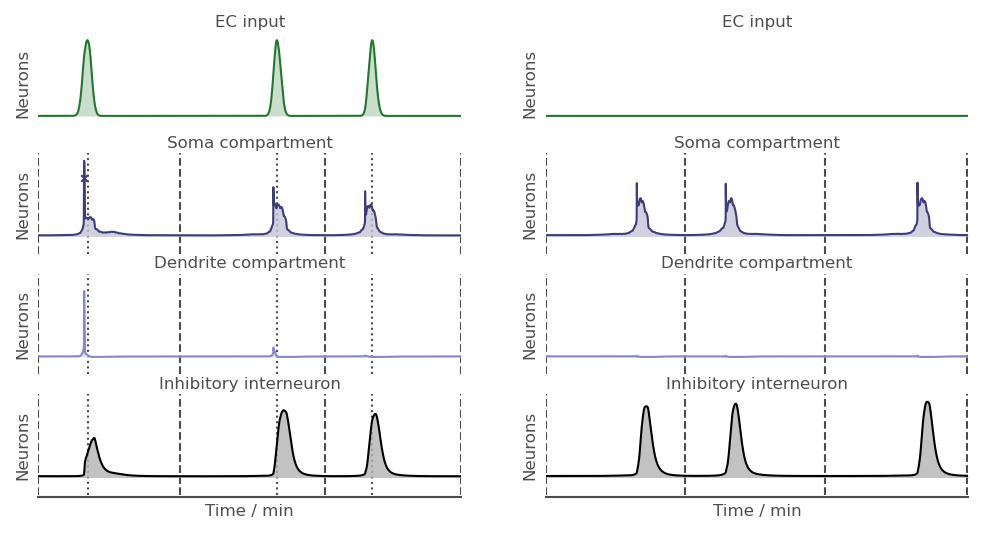

In [31]:
axes = plot_before_vs_after(Pyrs, Objs, disap_start_time=disap_start_time, pre=2.5 * 60, Pyrs_norm_by="shared_max")

In [86]:
def plot_before_vs_after_dendrite(Pyrs, disap_start_time=0, pre=60, ylims=None, together=False, ax=None):

    if ax is None:
        n_cols = 1 if together else 2
        fig, ax = plt.subplots(1, n_cols, figsize=(6, 4), sharex=True, sharey=True)
    else:
        num_subplots = np.asarray(ax).size
        if num_subplots != (2 - int(together)):
            raise ValueError("If ax is provided, it must include 1 subplot if together is True, and 2 otherwise.")
        fig = np.asarray(ax).ravel()[0].figure

    dt = Pyrs.Agent.dt
    t = np.asarray(Pyrs.DendriteCompartment.history["t"])
    positions = np.asarray(Pyrs.DendriteCompartment.Agent.history["pos"])
    firingrates = np.asarray(Pyrs.DendriteCompartment.history["firingrate"])
    
    # pre
    pre_ids = plot_util.get_plotting_times(
        t, t_start=disap_start_time - pre, t_end=disap_start_time,
    )

    # post
    post_ids = plot_util.get_plotting_times(
        t, t_start=disap_start_time, t_end=None,
    )

    pts_per_sec = int(0.5 / dt)

    colors = ["red", "grey"]
    labels = ["with object", "after obj. removal"]
    for i, (start_id, end_id) in enumerate(zip(pre_ids, post_ids)):
        s = 0 if together else i
        sub_ax = np.asarray(ax).ravel()[s]
        rates = firingrates[start_id:end_id, 0]
        peak_pts = gen_util.get_minima_indices(-rates, minimum=-0.1)
        responses = np.full((5 * pts_per_sec, len(peak_pts)), np.nan)
        for p, peak_pt in enumerate(peak_pts):
            pre_peak_pt = max(0, peak_pt - pts_per_sec)
            post_peak_pt = min(peak_pt + 4 * pts_per_sec, len(rates))
            response = rates[pre_peak_pt : post_peak_pt]
            time = np.linspace(-0.5, 2, post_peak_pt - pre_peak_pt)
            sub_ax.plot(
                time,
                response, 
                color=colors[i],
                alpha=0.4,
                lw=1,
            )
            
            start = pre_peak_pt - peak_pt + pts_per_sec
            responses[start : start + len(response), p] = response

        time = np.linspace(-0.5, 2, len(responses))
        response_mean = np.nanmean(responses, axis=1)

        sub_ax.plot(
            time,
            response_mean,
            color=colors[i],
            alpha=0.6,
            lw=3,
            ls="dashed",
            label=labels[i]
        )

        if i == 1 and not together:
            ax[0].fill_between(
                time,
                np.zeros_like(response),
                response_mean,
                color=colors[i],
                alpha=0.4,
                lw=0,
            )
        
        sub_ax.axvline(0, color="k", zorder=-3, alpha=0.5, lw=1.5, ls="dashed")
        sub_ax.set_xlabel("Time (s)") 
        sub_ax.spines[["top", "right"]].set_visible(False)
        if ylims is not None:
            sub_ax.set_ylim(*ylims)
    
        sub_ax.set_ylabel("Firing rates")

    sub_ax.legend()
    fig.suptitle("Comparing Pyr. dendrite activity at target before and after removal", y=1.0)

    return ax

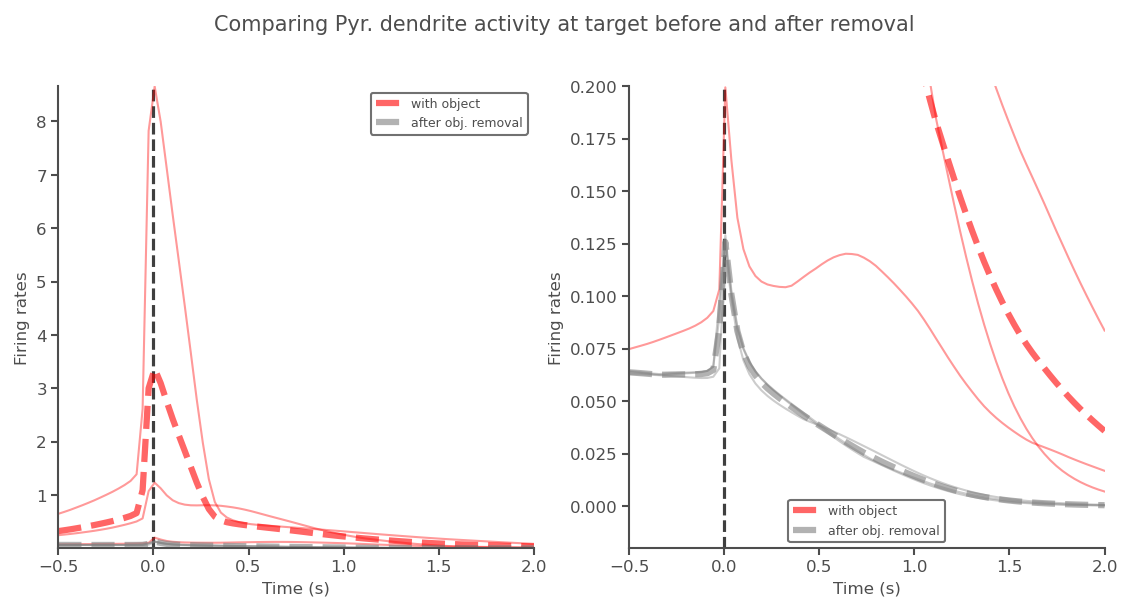

In [92]:
pre = 2.5 * 60

fig, ax = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=False)
plot_before_vs_after_dendrite(Pyrs, disap_start_time=disap_start_time, pre=pre, together=True, ax=ax[0]);
plot_before_vs_after_dendrite(Pyrs, disap_start_time=disap_start_time, pre=pre, ylims=(-0.02, 0.2), together=True, ax=ax[1]);